# **DIDA 325 Final Project: Analyzing the Apartmemts Dataset**
### **Group Members: Kate Aldrich, Stella Hung, Malayka Mudassar, Sarah Toniuk**

# **1. Introduction:**


Our imagined position on the dataset would be a team of analysts working with a program/website/app to get people to view the apartments in their area with pictures, and more specific information on that apartment such as: amenities, bathrooms, bedrooms and fee. The overall goals are to showcase the similarities apartments in the area have in common, what is the best choice for people with different expectations/requirements and to see how rent ranges in different places.

The dataset is derived from the UC Irvine Machine Learning Repository. Our approach to analyzing this dataset is to make research questions, build regression models and make visualizations (after cleaning data and dropping missing data as needed), and look at specific variables and see their impacts one way or another on other variables.


While examining this dataset, some questions we had were:

1. **Pandas and Data Visualization:** What factors highly influence apartment rental prices across different cities and categories?
2. **Regression:** How accurately can we predict the price of the apartment based on the number of rooms, fee, state, and even currency provided?
3. **Classification**: Based on its square footage, can we predict if the apartment has a high or low price?
4. **Miscellaneous:** Do higher rental cost (greater than $1500 a month) apartments tend to have photos listed on the websites?



# **2. Dataset:**


The dataset is derived from the UC Irvine Machine Learning Repository.
The columns are below, and what they represent:
* id: numeric; id number of the apartment
* amenitites: categorical; the amenities the apartment includes, if any
* bathrooms: numeric; the number of bathrooms included in the apartment
*   bedrooms: categorical; the number of bedrooms included in the apartment
*   currency: categorical; the currency that the price of the apartment is in
*   fee: categorical; if the apartment has a fee included (yes/no)
*   has_photo: categorical; if there is a photo included for the apartment (yes/no)
*   pets_allowed: categorical; if pets are permitted in the apartment (yes/no)
*   price: numeric; price of the apartment
*   price_display: categorical; how the price is listed on the website
*   price_type: categorical; the length of time between payments for the price (monthly, yearly, etc)
*   square_feet: numeric; dimensions of the apartment floor size, how much space
*   address: categorical; location of the apartment
*   cityname: categorical; city that the apartment is located in
*   state: categorical; state that it is located in
*   latitude: numeric; latitude coordinate of the location
*   longitude: numeric; longitude coordinate of the location
*   source: text; website of origin for the listing
*   time: numeric; listing time posted

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
with open("/content/apartments_for_rent_classified_10K.csv", encoding='utf-8', errors='ignore') as file:
    apartments10k = pd.read_csv(file, delimiter=";", on_bad_lines='skip')

apartments10k.head(5)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [ ]:
apartments10k = apartments10k[["bathrooms", "price", "bedrooms", "currency", "fee", "has_photo", "square_feet", "state"]]

#### **2.1: Question One:**


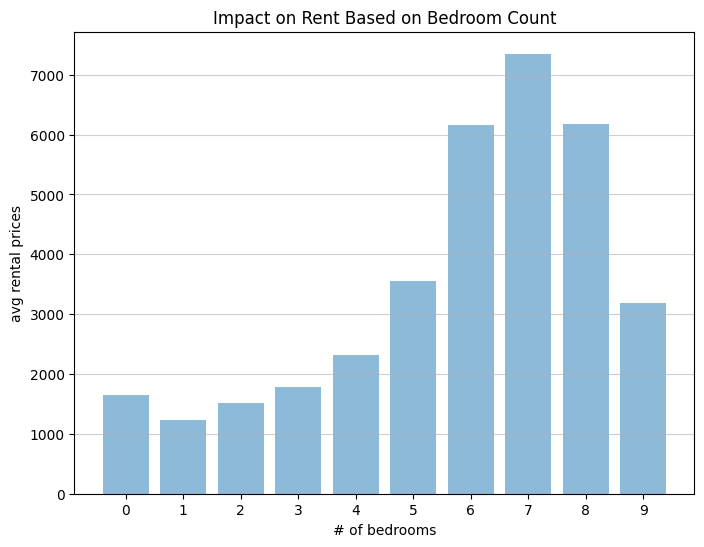

In [ ]:
bedroom_to_price = apartments10k.groupby("bedrooms")["price"].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.bar(bedroom_to_price["bedrooms"], bedroom_to_price["price"], alpha=0.5)
plt.title("Impact on Rent Based on Bedroom Count")
plt.xlabel("# of bedrooms")
plt.ylabel("avg rental prices")
plt.xticks(bedroom_to_price["bedrooms"])
plt.grid(axis='y', alpha=0.6)
plt.show()

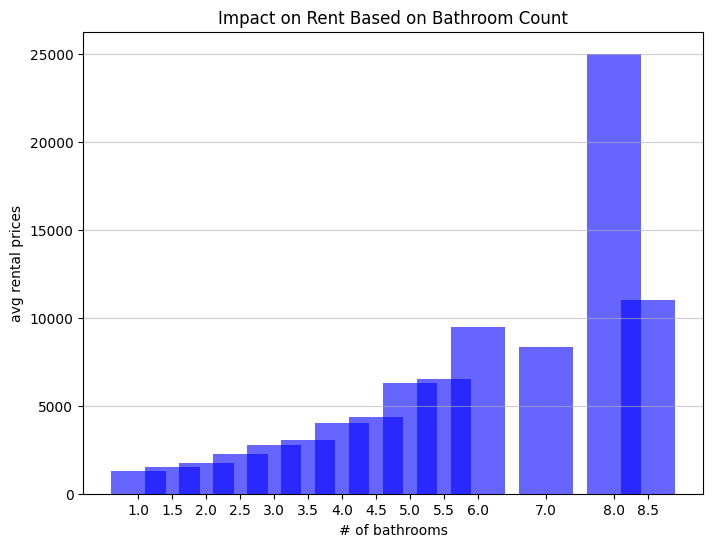

In [ ]:
bathroom_to_price = apartments10k.groupby("bathrooms")["price"].mean().reset_index()

plt.figure(figsize=(8, 6))
plt.bar(bathroom_to_price["bathrooms"], bathroom_to_price["price"], alpha=0.6, color= "blue")
plt.title("Impact on Rent Based on Bathroom Count")
plt.xlabel("# of bathrooms")
plt.ylabel("avg rental prices")
plt.xticks(bathroom_to_price["bathrooms"])
plt.grid(axis='y', alpha=0.6)
plt.show()

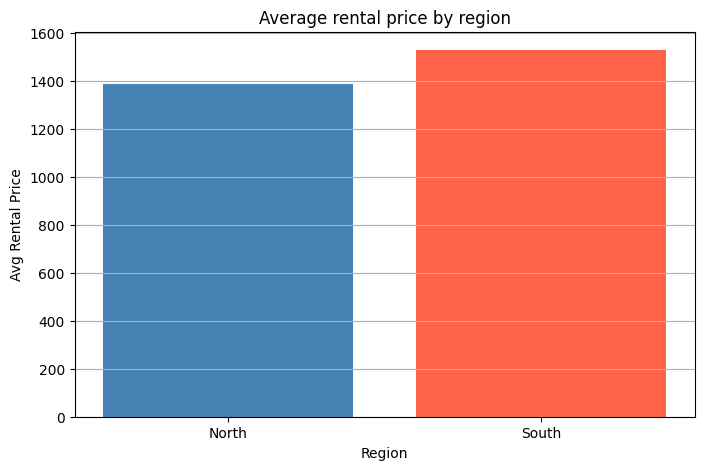

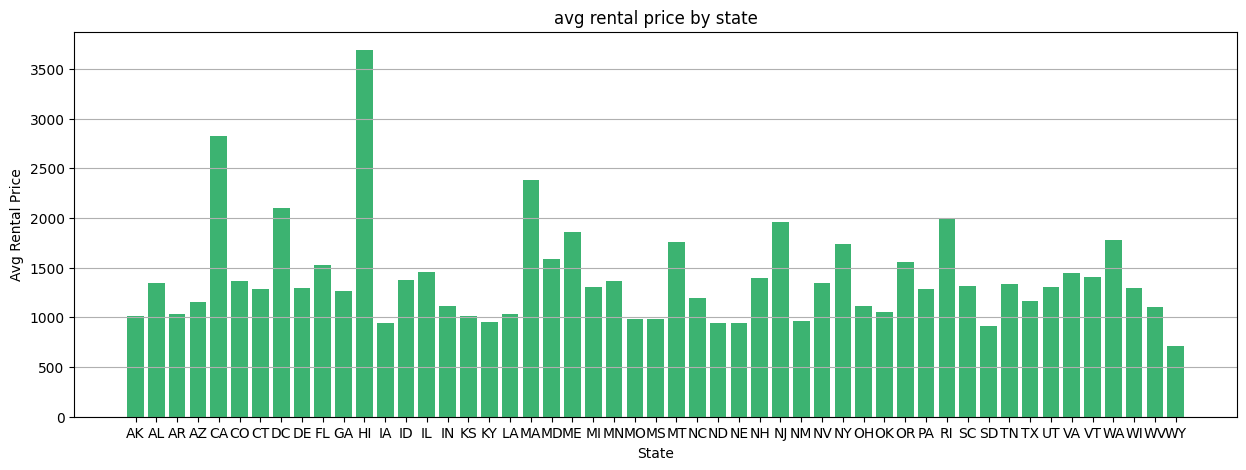

In [ ]:
region_mapping = {
       "North": ["ME", "NH", "VT", "MA", "CT", "RI", "NY", "NJ", "PA", "OH", "MI", "IN", "IL", "WI", "MN", "IA", "ND", "SD", "NE"],
    "South": ["AL", "AR", "FL", "GA", "KY", "LA", "MS", "NC", "SC", "TN", "TX", "VA", "WV"]
}

apartments10k["region"] = apartments10k["state"].map(lambda x: "North" if x in region_mapping["North"] else "South")
region_price = apartments10k.groupby("region")["price"].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(region_price["region"], region_price["price"], color=['steelblue', 'tomato', 'gray'])
plt.title("Average rental price by region")
plt.xlabel("Region")
plt.ylabel("Avg Rental Price")
plt.grid(axis='y')
plt.show()


state_price = apartments10k.groupby("state")["price"].mean().reset_index()

plt.figure(figsize=(15, 5))
plt.bar(state_price["state"], state_price["price"], color = "mediumseagreen")
plt.title("avg rental price by state")
plt.xlabel("State")
plt.ylabel("Avg Rental Price")
plt.grid(axis='y')
plt.show()




**Analysis:**
**We can see from the graphs here that bathroom and bedroom count affect rent significantly. Demand for both max out at a certain point (7 bedrooms, 8 bathrooms). In addition, while the difference in rent between the Northern and Southern states is about $100, a breakdown of all the states in the dataset shows the difference in average rent prices between each state.**

#### **2.2: Question Two:**

In [ ]:
apartments10k = apartments10k.dropna()
X = apartments10k[["bathrooms", "bedrooms", "currency", "fee", "state"]]
y = (apartments10k["price"]).astype("float32")

X = pd.get_dummies(X, drop_first=True).astype("float32")

In [ ]:
X = sm.tools.tools.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     129.3
Date:                Thu, 12 Dec 2024   Prob (F-statistic):               0.00
Time:                        02:01:42   Log-Likelihood:                -80465.
No. Observations:                9883   AIC:                         1.610e+05
Df Residuals:                    9830   BIC:                         1.614e+05
Df Model:                          52                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        113.5462    126.819      0.895      0.3

In [ ]:
yhat = model.predict()
residuals = y - yhat

In [ ]:
separatedDF = pd.DataFrame({
    'yhat': yhat,
    'residuals': residuals
})
threshold = 10000
high_residuals = separatedDF[separatedDF['residuals'] > threshold]


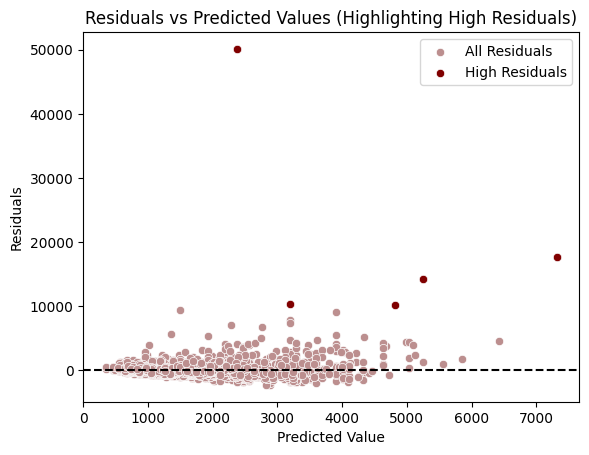

In [ ]:
ax = sns.scatterplot(x=separatedDF['yhat'], y=separatedDF['residuals'], color="rosybrown", label="All Residuals")
ax.axhline(y=0, color='black', linestyle='dashed')

sns.scatterplot(x=high_residuals['yhat'], y=high_residuals['residuals'], color="maroon", label="High Residuals", ax=ax)

plt.xlabel("Predicted Value")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Highlighting High Residuals)")
plt.legend()
plt.show()

In [ ]:
np.std(residuals)

831.1531507366242

In [ ]:
mae = mean_absolute_error(y, yhat)
print(f"Mean Absolute Error (MAE): {mae}")

mse = mean_squared_error(y, yhat)
print(f"Mean Squared Error (MSE): {mse}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

r2 = r2_score(y, yhat)
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 390.55217489477604
Mean Squared Error (MSE): 690815.5599794172
Root Mean Squared Error (RMSE): 831.1531507366241
R² Score: 0.40616354062449966


**Analysis:**
**The R-squared value is 0.406, indicating that approximately 40.6% of the variation in apartment prices is explained by the predictor variables included in the model. The Prob (F-statistic) is 0.000, indicating that the overall model is statistically significant at a 99% confidence level. Several variables exhibit strong statistical significance, as indicated by their p-values being less than 0.05. These include:**
* **Bathrooms: This variable has a positive coefficient (623.206) and is statistically significant (p-value < 0.05), meaning the number of bathrooms is strongly associated with higher apartment prices.**
* **Bedrooms: Similarly, the number of bedrooms has a positive and significant effect on price (coefficient = 95.7410, p-value < 0.05).**
* **States like CA (California) and HI (Hawaii) have large positive coefficients (1639.254 and 1995.913, respectively), indicating that apartments in these states are priced significantly higher compared to the reference category (the omitted state).**
* **Some states, such as AZ (Arizona) and WY (Wyoming), show negative coefficients, suggesting that apartments in these states are priced lower relative to the reference category.**

**The MAE indicates that, on average, the model's predictions deviate from the actual apartment prices by approximately $390.55. The MSE measures the average squared deviation between predicted and actual values. The high value of 690,815.56 suggests that the model struggles to accurately predict outliers or extreme values.**

#### **2.3: Question Three:**

In [ ]:
apartments10k = apartments10k.dropna()

X = apartments10k["square_feet"]
y = apartments10k["price"]

X = sm.tools.tools.add_constant(X)
model = sm.OLS(y,X).fit()
print(model.summary())

Text(0, 0.5, 'Residual')

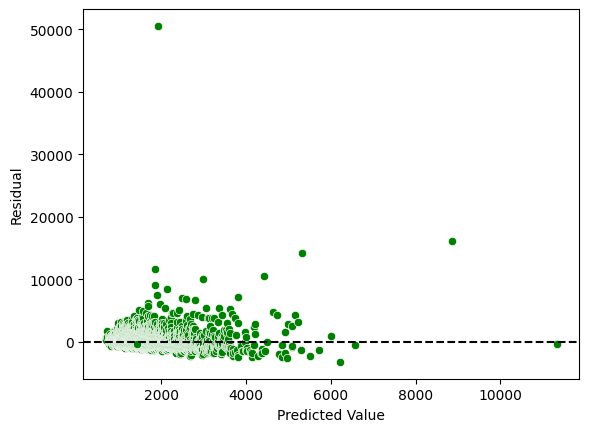

In [ ]:

yhat = model.predict()
residuals = y - yhat

ax=sns.scatterplot(x=yhat,y=residuals, color = "green")
ax.axhline(y=0,color="black",linestyle="dashed")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")

In [ ]:
np.std(residuals)

955.7191949764126

In [ ]:
mae = mean_absolute_error(y, yhat)
print(f"Mean Absolute Error (MAE): {mae}")

mse = mean_squared_error(y, yhat)
print(f"Mean Squared Error (MSE): {mse}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

r2 = r2_score(y, yhat)
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 520.9296176038791
Mean Squared Error (MSE): 913399.1796463628
Root Mean Squared Error (RMSE): 955.719194976413
R² Score: 0.2148269867374677


**Analysis: From both the regression model and the plot, we can see that the variable of square footage is statistically significant to the data, but is not the most important factor. This can be concluded from the P-value for square footage of 0.00 as well as the coefficient of 0.948. This suggests a positive, although rather small, relationship between square feet and price of apartments. Since the coefficient is small and close to 1, the correlation is slight but is still statistically significant since the P-value is less than 0.05.The r-squared value of 0.215 indicates that approximately 21.5% of the variance in apartment prices is explained by the variable of square footage. There are also a few outliers in the data that we can observe from the regression plot which may contribute to lower accuracy or poor fit of the data.**

**The MAE indicates that, on average, the model's predictions deviate from the actual apartment prices by approximately $520.93. The high MSE value of 913399.18 indicates that there could be inaccurate predictions in the data such as poor fit or overfitting. The presence of outliers, which we can see in the regression plot, can also increase the MSE value.**

#### **2.4: Question Four:**

In [ ]:
apartments10k = apartments10k.dropna()
X4 = apartments10k[["bathrooms", "bedrooms", "currency", "fee", "has_photo", "square_feet"]]
y4 = (apartments10k["price"]>=1500).astype("float32")

X4 = pd.get_dummies(X4, drop_first=True).astype("float32")

In [ ]:
X4 = sm.tools.tools.add_constant(X4)

model = sm.Logit(y4, X4).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.566436
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                 9883
Model:                          Logit   Df Residuals:                     9877
Method:                           MLE   Df Model:                            5
Date:                Thu, 12 Dec 2024   Pseudo R-squ.:                  0.1206
Time:                        02:29:34   Log-Likelihood:                -5598.1
converged:                       True   LL-Null:                       -6365.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -2.2505      0.167    -13.450      0.000      -2.578      -1.923
ba

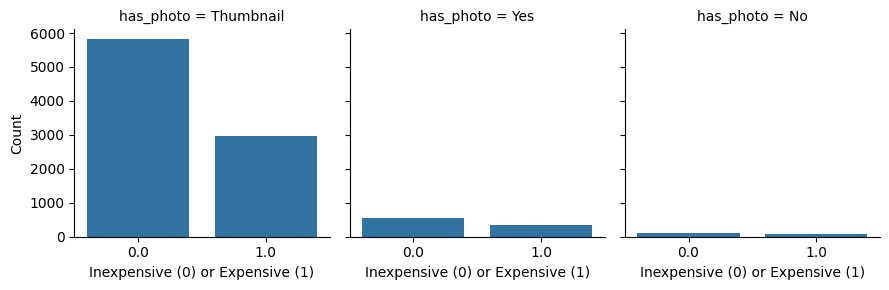

In [ ]:
apartments10k['y4'] = (apartments10k["price"] >= 1500).astype("float32")
grid = sns.FacetGrid(apartments10k, col="has_photo", col_wrap=3)
grid.map_dataframe(sns.countplot, x="y4")
grid.set_axis_labels("Inexpensive (0) or Expensive (1)", "Count")

**Analysis: As we can see in the data and the visualization, having photos listed on the website does not have any significant correlation with whether the apartment is expensive or not. For the purposes of simplicity, we have defined "expensive" as being over $1500 in monthly rent based on personal thoughts and people on the internet (in forums such as Reddit) agreeing that 1500 is a good benchmark.**

**However, what is interesting about this data is that whether it has a thumbnail photo or not is statistically significant and it actually shows an inverse relationship from what I expected. More inexpensive apartments have photos than expensive.**

**As well, another surprising factor looking at the logistic regression is that square feet, although statistically significant, has a small coefficient and thus little correlation. Then again, this could be attributed to houses with more bedrooms having cheaper rent and bigger square feet (assuming the rent on the websites listed is per person rather than for the whole building).**

# **3. Conclusions:**

Restate the results of your research questions. Was your analysis effective, or might a more sophisticated approach be better? Was there something missing from the dataset that would enabled a more in-depth analysis?

**The main goal is to examine the relationship between apartment characteristics and rental prices.**
**Our goal is to identify rental price trends in different areas and recommend better options for users with different preferences. We also wanted to find patterns in rent variations.**


**Main findings:**
**A relationship was identified between certain apartment characteristics (such as the # of bedrooms and bathrooms) and the rental price.**

**Regional variations in average rental prices were visualized effectively, highlighting how location impacts rent and affordability.**

**The analysis addressed key aspects of the dataset, providing meaningful visualizations such as bar charts and region-specific pricing trends.**

**For question two:**
**Based on the regression model, plot and analysis, the model predicts apartment prices with moderate accuracy, as it explains 40.6% of the variance in prices (R² = 0.406), with statistically significant predictors like the number of bathrooms, bedrooms, and state contributing meaningfully to price variations. While the analysis effectively identifies key predictors, exploring non-linear models could perhaps improve its ability to handle outliers and enhance overall predictive accuracy.**

**Question Three:**
**Based on the regression model, plot, and analysis, it can be observed that the variable of square footage has a positive and stastically significant relationship to the price of apartments, however it is a very small correlation. The analysis suggests that there could be innacurate predictions or low accuracy in the data, so improvements could be helpful in order to better predict the impact of square footage on price of apartments.**

**Question Four:**
**The model predicts that having a photo in the thumbnail has a negative correlation to the price being expensive. It is statistically significant, however, listings having a photo in general does not have a statistically significant impact. I feel that this may be due to a lack of data, because higher end apartments tend to have photos accompanying their listings. However, it may be worth seeing if, by changing the threshold for what is considered expxensive, it may change the results of the regression model.**